# Broadband CMOS RGB image sensor

BeamZ reproduction of the [published Tidy3D sensor](https://www.flexcompute.com/tidy3d/examples/notebooks/CMOSRGBSensor/), using **the exact embedded material coefficients**, including RGB filters and aluminum. One device simulation plus one empty-cell calibration measures the full visible band; there is no wavelength sweep.

The 25 nm uniform grid below is a quick reproducible baseline on the RTX 3090. Separate graded-grid runs refine metal and detector interfaces to 5 nm. Their results and the remaining convergence limits are in `docs/reviews/cmos-reference-parity`. Optical efficiency is detector-aperture flux divided by incident power over the entire Bayer cell; it is not electrical quantum efficiency.

The earlier notebook used filters with excessive passband loss and a different aluminum model with the same library name. Both have been replaced. The numerical reference spectra have not been exported from Tidy3D, so comparisons with its displayed efficiency plot remain approximate.

In [1]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import jax
import beamz as bz

root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "examples/cmos_rgb_sensor.py").exists())
sys.path.insert(0, str(root / "examples"))
from cmos_rgb_sensor import make_sim, load_materials, pixel_signs, plot_rgb_fields

print("JAX devices:", jax.devices())
test_mode = os.environ.get("BEAMZ_DOCS_TEST") == "1"
dx = (100 if test_mode else 25) * bz.nm
run_time = (100 if test_mode else 510) * 1e-15
num_freqs = 31 if test_mode else 200
frequencies = np.linspace(bz.LIGHT_SPEED/(700*bz.nm), bz.LIGHT_SPEED/(400*bz.nm), num_freqs)
wavelengths = bz.LIGHT_SPEED / frequencies


JAX devices: [CudaDevice(id=0)]


## Exact reference materials

All seven material models come from the simulation embedded in the published page, saved locally with provenance and checksums. Pole/residue frequency units are SI rad/s. The RGB passbands must satisfy k ≤ 0.02 on the target CSV transparent bands; the actual central values are near 0.01.

The embedded aluminum has four real pole pairs, unlike the five-pair library model previously used. Matching names alone did not reproduce its optical response. The old models are preserved for comparison. Volume averaging remains the baseline interface treatment; convergence must be established numerically.

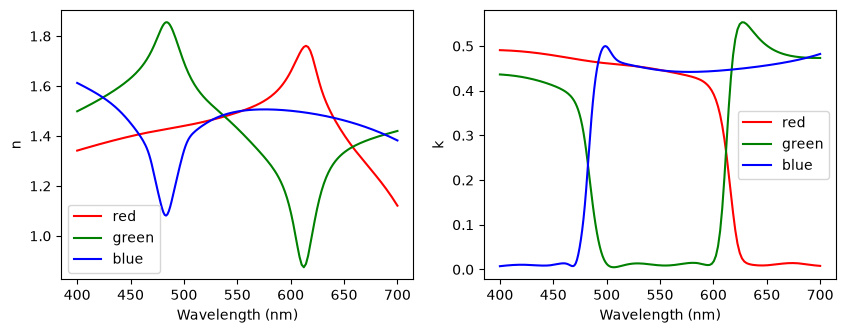

red at 650 nm: n=1.4045, k=0.00917
green at 550 nm: n=1.4304, k=0.00904
blue at 450 nm: n=1.4516, k=0.01016
Aluminum epsilon at 550 nm: (-21.901043344449196+74.8586471102467j)


In [2]:
materials = load_materials()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for name, color in (("red", "r"), ("green", "g"), ("blue", "b")):
    nk = np.sqrt(materials[name].eps_model(frequencies))
    axes[0].plot(wavelengths / bz.nm, nk.real, color, label=name)
    axes[1].plot(wavelengths / bz.nm, nk.imag, color, label=name)
for axis, label in zip(axes, ("n", "k")):
    axis.set(xlabel="Wavelength (nm)", ylabel=label)
    axis.legend()
plt.show()
for channel, wl in (("red",650),("green",550),("blue",450)):
    nk = np.sqrt(materials[channel].eps_model(bz.LIGHT_SPEED/(wl*bz.nm)))
    print(f"{channel} at {wl} nm: n={nk.real:.4f}, k={nk.imag:.5f}")
print("Aluminum epsilon at 550 nm:", materials["metal"].eps_model(bz.LIGHT_SPEED / (550*bz.nm)))


## Geometry and setup

The 3 × 3 µm RGGB unit cell includes four silica lens caps, filters, an aluminum shield with a circular opening, interconnects, a SiN antireflection layer, and an amorphous-silicon detector. The shield opening uses an explicit z coordinate. The SiN thickness is evaluated from its optical index at 550 nm.


Grid: (120, 120, 285) steps: 15134 dt: 3.370208102706291e-17


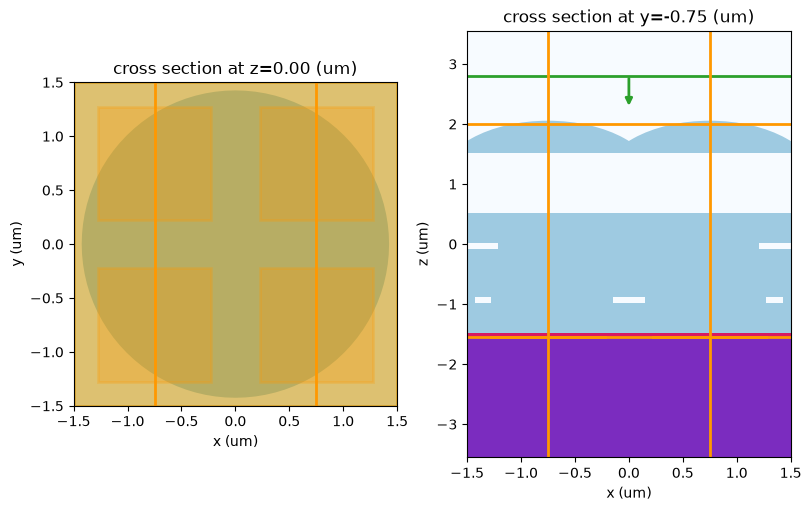

In [3]:
simulation = make_sim(dx=dx, run_time=run_time, num_freqs=num_freqs)
print("Grid:", simulation.grid.shape, "steps:", simulation.num_steps, "dt:", simulation.dt)
fig, axes = simulation.plot(y=-0.75*bz.um, figsize=(8, 5), show=False)
plt.show()


## Run the broadband device

Flux monitors collect the same 200 frequency samples as the reference notebook. Field monitors collect all three electric components at 450, 550, and 650 nm, interpolated to common monitor locations. The 510 fs runtime covers the reference maximum runtime without relying on a nondispersive automatic energy-stop criterion.

In [4]:
result = simulation.run(backend="jax", progress=not test_mode)
print("Device run complete.")


* Compiling simulation...

* Running simulation: [--------------------] 0% (0/15134 steps)

* Running simulation: [#-------------------] 5% (757/15134 steps)

* Running simulation: [##------------------] 10% (1514/15134 steps)

* Running simulation: [###-----------------] 15% (2271/15134 steps)

...

* Running simulation: [#################---] 85% (12869/15134 steps)

* Running simulation: [##################--] 90% (13626/15134 steps)

* Running simulation: [###################-] 95% (14383/15134 steps)

* Running simulation: [####################] 100% (15134/15134 steps)

Simulation runtime: 180.42 s
GCUPS: 0.344
Device run complete.


## Incident-power calibration

One empty-cell broadband reference provides P₀(f) using the same source, grid, aperture, and acquisition time. Reference calibration corrects finite-grid source and flux-sampling errors. This is a second broadband run, not a wavelength sweep.


* Compiling simulation...

* Running simulation: [--------------------] 0% (0/15134 steps)

* Running simulation: [#-------------------] 5% (757/15134 steps)

* Running simulation: [##------------------] 10% (1514/15134 steps)

* Running simulation: [###-----------------] 15% (2271/15134 steps)

...

* Running simulation: [#################---] 85% (12869/15134 steps)

* Running simulation: [##################--] 90% (13626/15134 steps)

* Running simulation: [###################-] 95% (14383/15134 steps)

* Running simulation: [####################] 100% (15134/15134 steps)

Simulation runtime: 89.90 s
GCUPS: 0.691


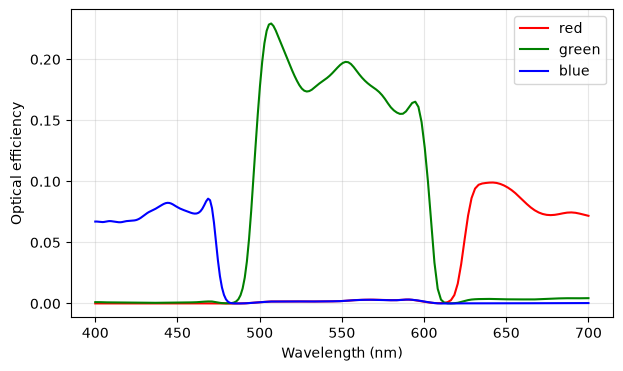

Central-wavelength optical efficiencies (computed, approximate interpolation):
red: 9.57%
green: 19.64%
blue: 7.89%


In [5]:
reference_simulation = make_sim(dx=dx, run_time=run_time, reference=True, fields=False, num_freqs=num_freqs)
reference = reference_simulation.run(backend="jax", progress=not test_mode)
incident_power = -np.asarray(reference["incident_plane"].flux)
assert np.all(np.isfinite(incident_power)) and np.all(incident_power > 0)
efficiency = {pixel: -np.asarray(result[f"flux_si_{pixel}"].flux) / incident_power for pixel in pixel_signs}
fig, ax = plt.subplots(figsize=(7, 4))
for name, color in (("red", "r"), ("green", "g"), ("blue", "b")):
    values = efficiency["green1"] + efficiency["green2"] if name == "green" else efficiency[name]
    ax.plot(wavelengths / bz.nm, values, color, label=name)
ax.set(xlabel="Wavelength (nm)", ylabel="Optical efficiency")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print("Central-wavelength optical efficiencies (computed, approximate interpolation):")
for channel, wl in (("red",650),("green",550),("blue",450)):
    y = efficiency["green1"] + efficiency["green2"] if channel == "green" else efficiency[channel]
    order = np.argsort(wavelengths)
    value = np.interp(wl*bz.nm, wavelengths[order], y[order])
    print(f"{channel}: {100*value:.2f}%")
# Save numerical outputs for the cross-grid comparison.
output = root / "docs/reviews/cmos-reference-parity/notebook25nm"
output.mkdir(parents=True, exist_ok=True)
np.savez(output/"calibrated_efficiency.npz", wavelength_nm=wavelengths/bz.nm,
         red=efficiency["red"], green=efficiency["green1"]+efficiency["green2"], blue=efficiency["blue"])


## Total electric-field intensity

These plots show **(|Ex|² + |Ey|² + |Ez|²) / |Eincident|²**, using the empty-cell field monitor for calibration. All three wavelength panels in each row share the same color scale. This replaces the earlier Ex-only plots. The reference webpage's absolute field plots use a different display normalization; these dimensionless maps make spatial and spectral comparisons interpretable.

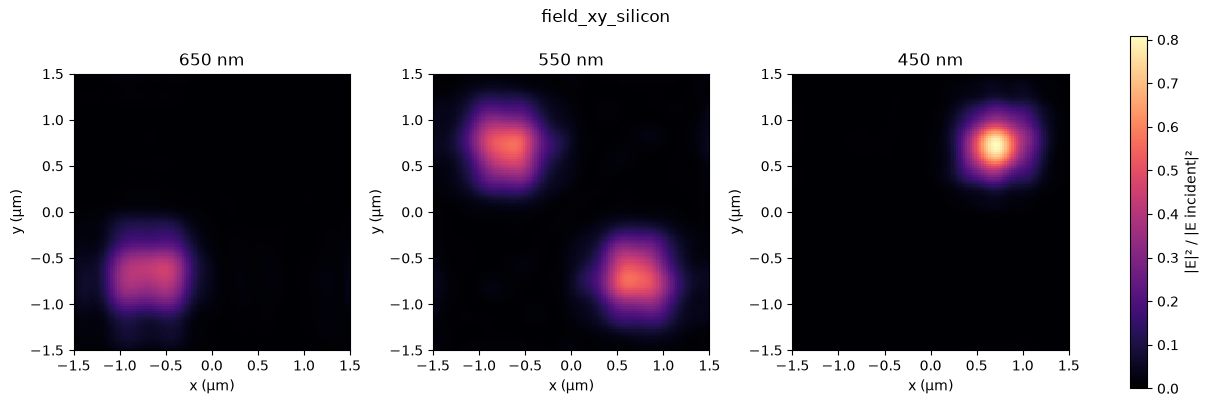

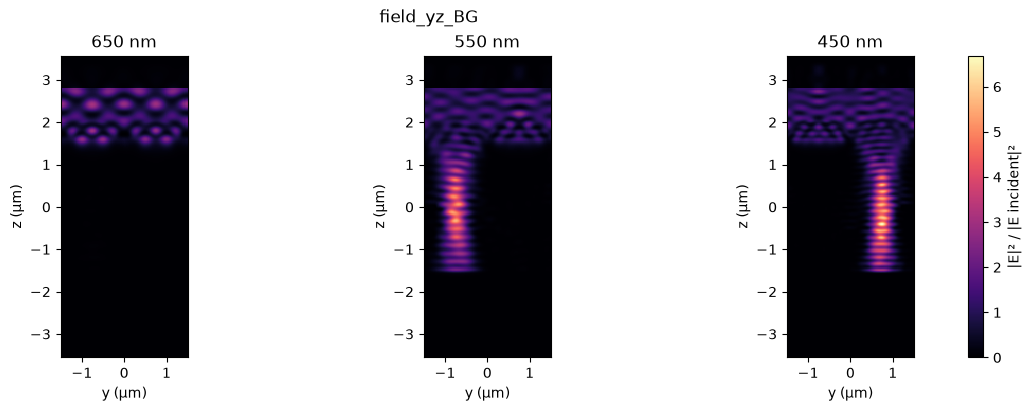

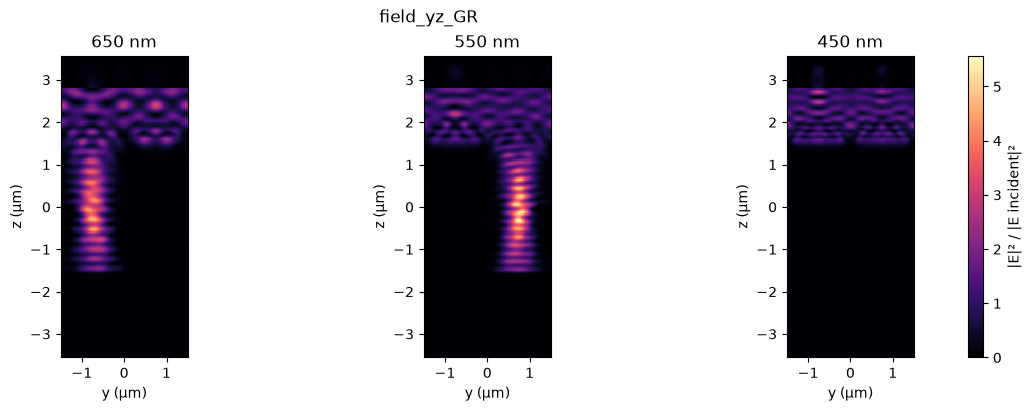

In [6]:
figures = plot_rgb_fields(result, reference)
for name, fig in zip(("field_xy_silicon", "field_yz_BG", "field_yz_GR"), figures):
    fig.savefig(output/f"{name}.png", dpi=150)
plt.show()

## Validation and remaining limits

- Exact imported materials are validated against the saved simulation snapshot, with explicit RGB passband checks.
- Normal plane-wave injection supports rectilinear meshes. Tests cover both directions on all three axes, incident power, and backward leakage.
- Flux integration clips edge-cell areas to the requested physical aperture. The reference uses the same realized grid and timestep as the device, including on graded meshes.
- Filter films, aluminum/aSi slabs, and a silica/SiN/aSi stack are checked against analytical thin-film optics on the RTX 3090.
- Graded-grid and absorber checks are saved in `docs/reviews/cmos-reference-parity`. Refining depth does not by itself establish convergence of lateral metal edges or curved lenses.

Reproduce the depth-refined run with `scripts/validation/run_cmos_broadband.py --graded --dx-nm 20 --metal-nm 5`, followed by the same command with `--reference`. The uniform notebook remains a faster baseline. No change here establishes electrical carrier collection or quantum efficiency.

## Saved RTX 3090 accuracy comparison

The notebook above uses one broadband device run and one empty-cell calibration,
with 200 frequency samples. The separate graded runs use 31 samples and 300 fs,
with 5 nm depth refinement; the uniform notebook uses 510 fs.

| Run | Red at 650 nm | Green at 550 nm | Blue at 450 nm |
| --- | ---: | ---: | ---: |
| Old materials, 25 nm | 3.15% | 5.78% | 1.22% |
| Exact materials, 25 nm | 9.57% | 19.64% | 7.89% |
| graded-20-5nm | 10.10% | 21.96% | 9.92% |
| graded-15-5nm | 10.15% | 21.98% | 9.92% |
| Published Tidy3D plot (approximate) | 6% | 20% | 6% |

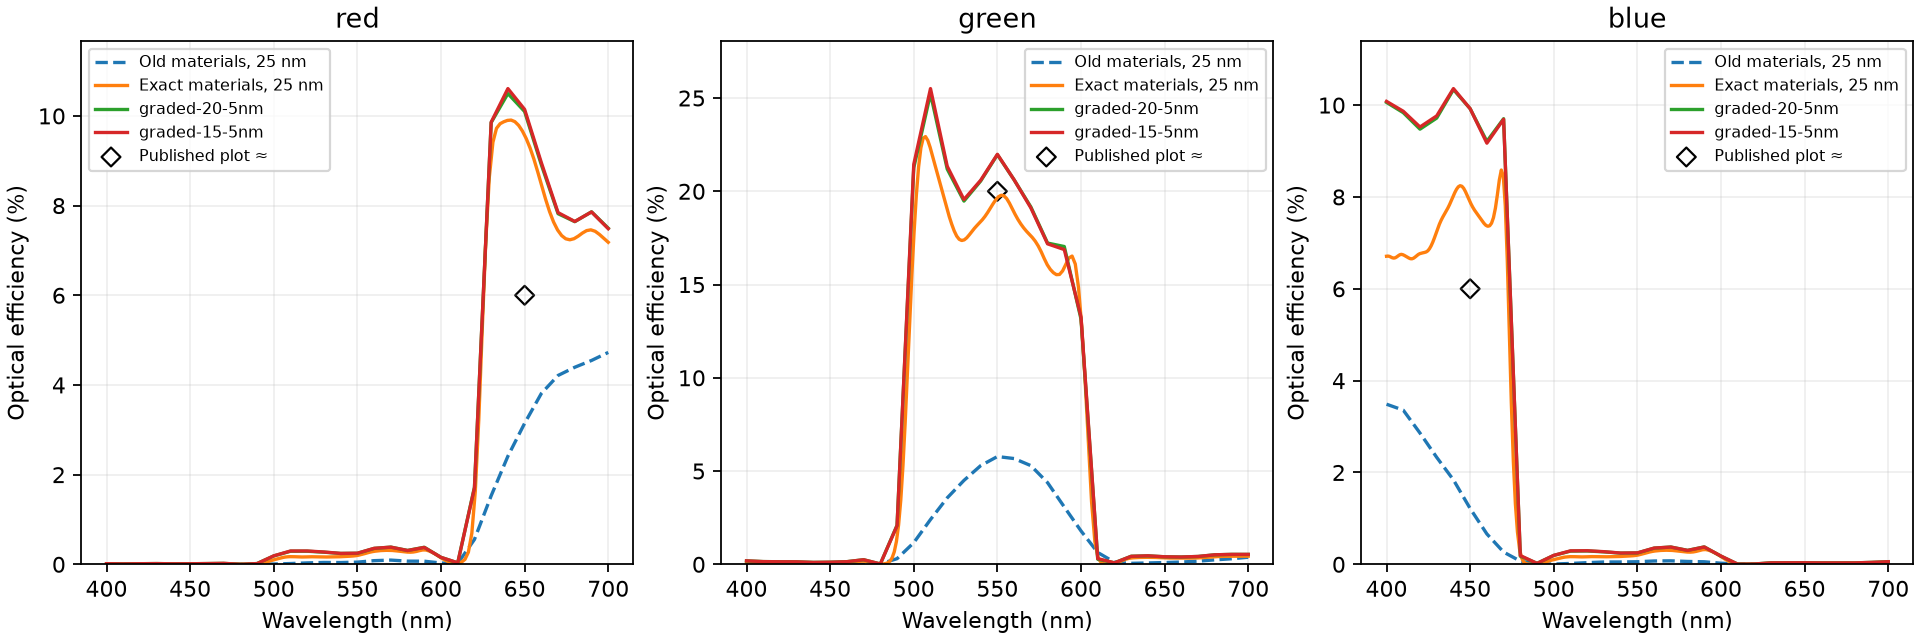

**Material parity does not yet establish numerical agreement.** Refining the
graded grid laterally from 20 to 15 nm changes the full spectra by at most
0.11, 0.28, and 0.05 percentage points for R/G/B, substantially less than the
remaining reference discrepancy. Both runs retained finite fields and material
polarization. Red and blue remain higher than the published figure.

The reference values above are visual estimates, not exported numerical flux
arrays. Independent planar tests identify a remaining flux-colocation error
exactly at the silicon interface. Depth/interface refinement and numerical
Tidy3D monitor exports are the next priorities; the detector plane has not been
moved to hide that error. The validation report and reproducible artifacts are
in `docs/reviews/cmos-reference-parity/README.md`.
